# IPL Data Analysis

This project analyzes IPL match data using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn to identify trends in team performance, toss decisions, player achievements, and venue statistics.

Load the libraries

In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

Load the dataset

In [49]:
df = pd.read_csv("IPL.csv")

Basic Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

Check the size of rows and columns of the dataset

In [7]:
print(f"your rows are {df.shape[0]} and columns are {df.shape[1]}")

your rows are 74 and columns are 20


Now let's see how many columns have null values in total.

In [8]:
df.isna().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

Which team won the most matches?

In [9]:
match_wins = df['match_winner'].value_counts()
match_wins

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Punjab        7
Delhi         7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

Text(0.5, 1.0, 'The most win match')

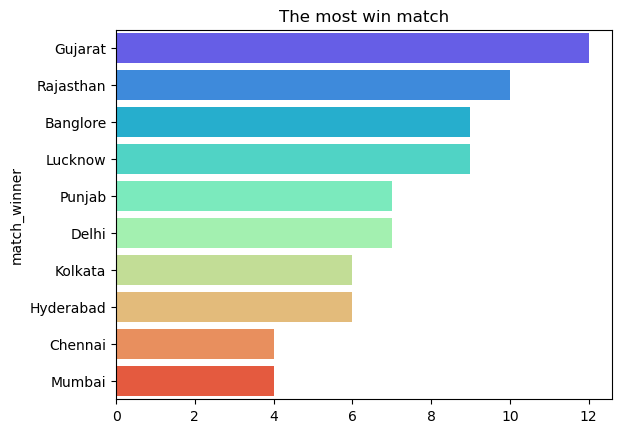

In [10]:
sns.barplot(x = match_wins.values,y= match_wins.index,palette='rainbow')
plt.title('The most win match')

Toss Decision Trends

Text(0.5, 1.0, 'Toss Decision Trends')

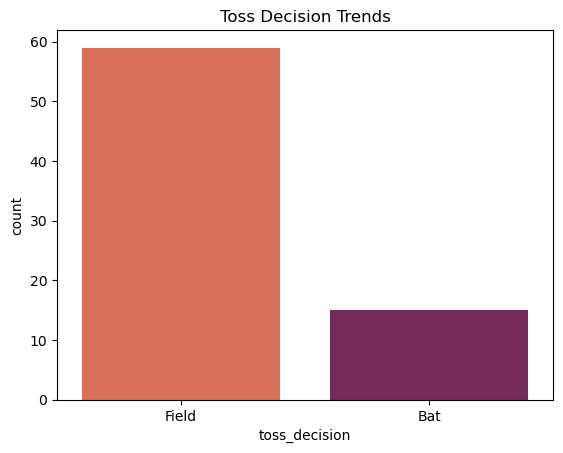

In [11]:
sns.countplot(x=df['toss_decision'],palette="rocket_r")
plt.title('Toss Decision Trends')

Toss Winner vs Match Winner

In [12]:
cnt = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
cnt

np.int64(36)

In [13]:
percentage = (cnt * 100)/df.shape[0]
percentage

np.float64(48.648648648648646)

In [14]:
percentage.round(2)

np.float64(48.65)

How do teams win? ( By Runs or By Wickets)

Text(0.5, 1.0, 'Team Won By')

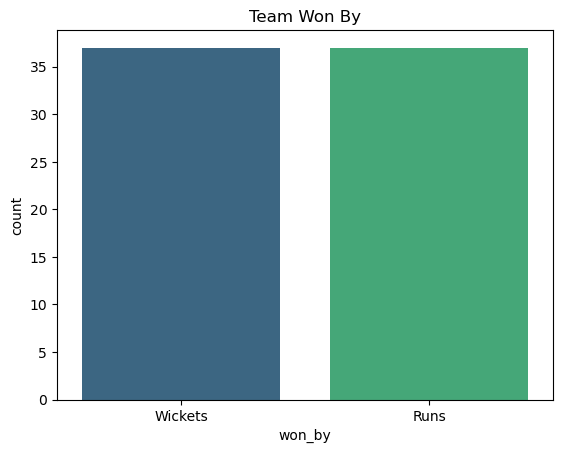

In [15]:
sns.countplot(x=df['won_by'],palette='viridis')
plt.title('Team Won By')

 Most "Player of the Match" Awards

In [16]:
player = df['player_of_the_match'].value_counts().head(10)
player

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Wanindu Hasaranga    2
Umesh Yadav          2
Quinton de Kock      2
Shubman Gill         2
Avesh Khan           2
Dinesh Karthik       2
Hardik Pandya        2
Rahul Tripathi       2
Name: count, dtype: int64

Text(0.5, 1.0, 'Player of the Match')

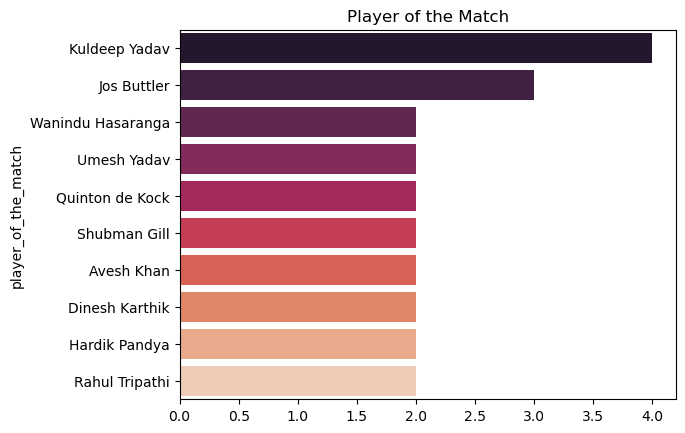

In [17]:
sns.barplot(x=player.values,y=player.index,palette="rocket")
plt.title('Player of the Match')

Top scorer

In [18]:
scorer = df.groupby('top_scorer')['highscore'].sum().head(2)
scorer

top_scorer
Abhishek Sharma    122
Aiden Markram       57
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

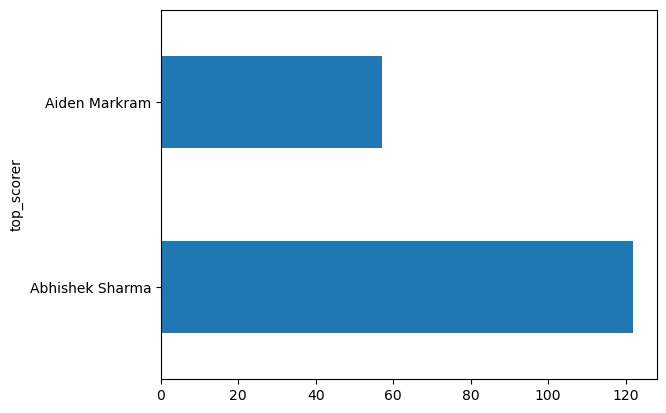

In [19]:
scorer.plot(kind='barh')

10 Best Bowling Figures

Text(0.5, 1.0, 'Top 10 Bowlers by Total Wickets')

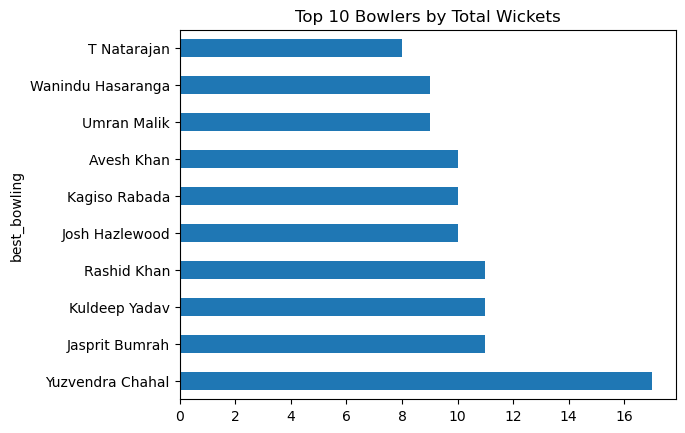

In [20]:
df['highest_wicket'] = df['best_bowling_figure'].apply(lambda x: x.split('--')[0])
df['highest_wicket'] = df['highest_wicket'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wicket'].sum().sort_values(ascending = False).head(10)
top_bowlers.plot(kind="barh")
plt.title("Top 10 Bowlers by Total Wickets")

Most Matches Played by Venue

In [21]:
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

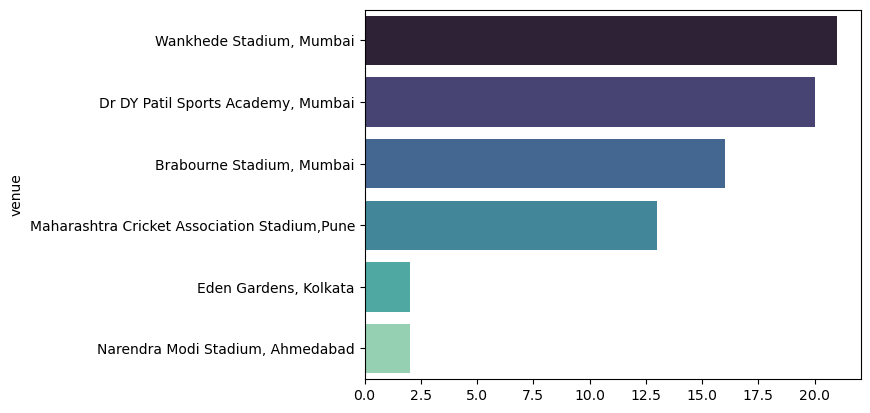

In [22]:
sns.barplot(x=venue_count.values,y=venue_count.index,palette='mako')

 Who won the highest margin by runs?

In [23]:
df[df['won_by'] == 'Runs'].sort_values(by='margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


 Which player had the highest individual score?

In [24]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


 Which bowler had the best bowling figures?

In [25]:
df[df['highest_wicket'] == df['highest_wicket'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10


Which players have won the most Player of the Match awards in IPL history?

Text(0.5, 1.0, 'Top 5 Players with Most Player of the Match Awards')

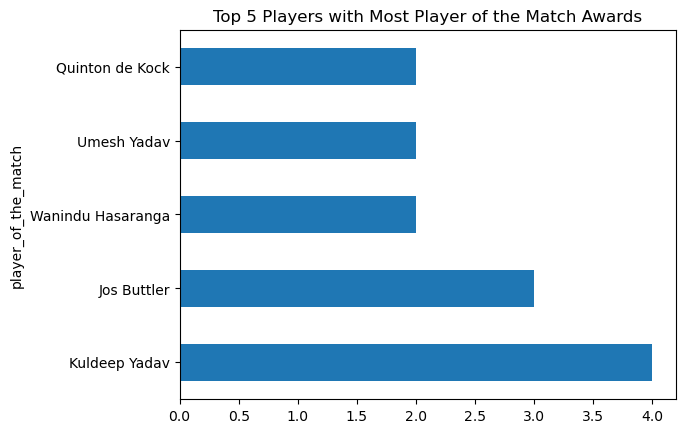

In [29]:
top_player = df['player_of_the_match'].value_counts().head(5)
top_player.plot(kind = 'barh')
plt.title("Top 5 Players with Most Player of the Match Awards")

Average First Innings Score by Venue

Text(0.5, 1.0, ' Venues by Average First Innings Score')

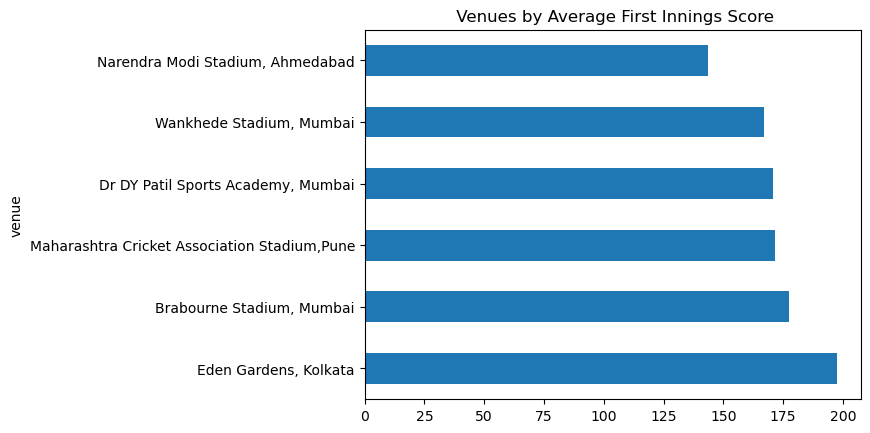

In [36]:
firstscore = df.groupby('venue')['first_ings_score'].mean().sort_values(ascending= False)
firstscore.plot(kind='barh')
plt.title(" Venues by Average First Innings Score")

What is the distribution of first innings scores in IPL matches?

Text(0.5, 1.0, 'Distribution of First Innings Scores')

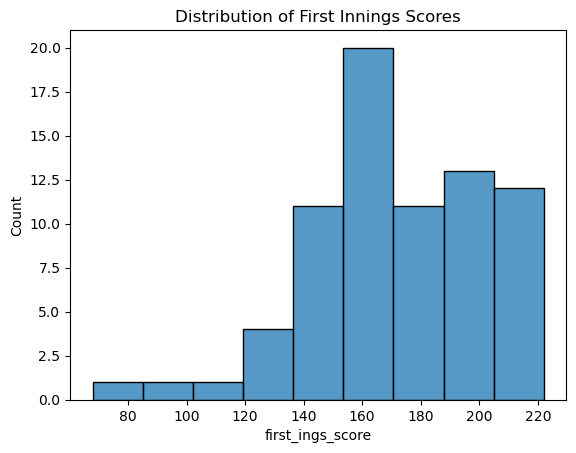

In [44]:
sns.histplot(df['first_ings_score'])
plt.title("Distribution of First Innings Scores")

Which tournament stage has the highest average first innings score?

Text(0.5, 1.0, 'Average First Innings Score by Stage')

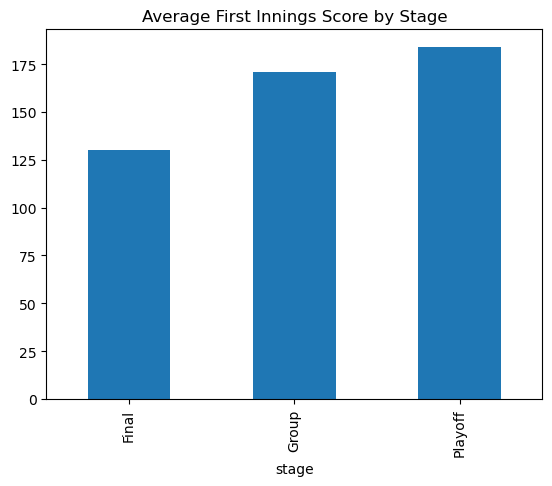

In [48]:
stage = df.groupby('stage')['first_ings_score'].mean()
stage.plot(kind='bar')
plt.title("Average First Innings Score by Stage")

## Key Findings

1. Winning the toss does not guarantee victory.
2. Certain venues are more batting friendly.
3. Top performers consistently influence match outcomes.
4. Scoring patterns vary across tournament stages.